## Loading Data

In [18]:
import pandas as pd
from itertools import groupby

filename = "user_journey_raw.csv"
user_journey_df = pd.read_csv(filename)
user_journey_df.head(4)

,user_id,session_id,subscription_type,user_journey
0,1516,2980231,Annual,Homepage-Log in-Log in-Log in-Log in-Log in-Lo...
1,1516,2980248,Annual,Other-Sign up-Sign up-Sign up-Sign up-Sign up-...
2,1516,2992252,Annual,Log in-Log in-Log in-Log in-Log in-Log in
3,1516,3070491,Annual,Homepage-Log in-Log in-Log in-Log in-Log in-Lo...


## Preprocessing Phase

### Preprocessing Class Definition

In [19]:

class PythonCapstonePreprocessing:
  """
  This is the preprocessing class for 365 Python Learning Track capstone project.
  It contains the following methods
  remove_duplicates:
  group_by:
  remove pages:
  """

  def __init__(self):
    pass

  def remove_duplicates(self, data:pd.DataFrame,
                        target_column:str)-> pd.DataFrame:
    """
      Function to remove duplicates from target column from a sequential list.

      args : data -> the dataframe/dataset.
            target_column -> the column with the sequential list with duplicates.

      return : a new dataframe with duplicates removed and order of sequence maintained.

    """
    try:
      data_dup_removed = data.copy()
      final = target_column.str.split("-")
      final = pd.Series(['-'.join([item for item, _group in groupby(row)]) for row in final])
      data_dup_removed['user_journey'] = final.values
      return data_dup_removed
    except Exception as e:
      print("Exception Raised at remove_duplicates(): ", e)



  def group_by(self, data:pd.DataFrame, group_column = 'user_id',
              target_column = 'user_journey',
              session = 'All', count_from = 'last'):
    """
    Args:
      data: data with duplicates removed
      group_column: column to group individual client's sessions by.
      target_column: user journeys column.
      session: how many sessions from group column to select
      count_from: direction to count and group the sessions from. (e.g first five sessions or last seven sessions)

    Returns: Returns a new dataframe with specified website usage journey sessions
             for a user grouped by user_id in a specific direction
    """
    group_column = str(group_column)
    all_user_journey = []


    # Selects the user_journey specific to the user_id and makes a list of them.
    # for num in pd.unique(group_column): Initial iteration but it does not specify the data for further callings.
    try:
      for num in data[group_column].unique():
        new_list = []
        new_list = data.loc[data[group_column] == num, target_column].tolist()
        #Specifies how to join the collated user journey list together based on session parameter
        #All for all session
        #If session == int, it combines the journey based on the value of the string and also the starting point
        #Using the count_from parameter, 'first' : takes from the first journey recorded till session value.
        #                                'last'  : joins using the last session value.
        if session == 'All':
          newer_list = '-'.join([item for item in new_list])
        elif isinstance(session, int) and count_from == 'first':
          newer_list = '-'.join([item for item in new_list[:session]])
        elif isinstance(session, int) and count_from == 'last':
          newer_list = '-'.join([item for item in new_list[-session:]])
        
        # subcription_type = data['subcription_type'].iloc[0]
        all_user_journey.append({'user_id' : num, 'user_journey' : newer_list})

      user_journey_df = pd.DataFrame(all_user_journey)
      return user_journey_df
    except Exception as e:
      print("Exception error at group_by(): ", e)


  def remove_pages(self, data, pages, target_column = "user_journey"):
    """
    Args:
      data: Dataframe with combined user journey from the group_by function.
      pages: Specifies the pages to remove from the dataframe.
      target_column: User_journey column containing collated journey.

    Returns: A new dataframe with pages removed as indicated in the pages attribute.
    """

    data_rem = data.copy()
    try:

      journey_list = data[target_column].str.split('-')

      # A function to remove items in pages from a single row list.
      def remove_from_list(journey, pages):
        result = []

        for i in journey:
          if i not in pages:
            result.append(i)
        return result

      # Applying the remove_from_list function to iterate through the lists in the
      # column.
      data_rem[target_column] = journey_list.apply(lambda x:'-'.join(remove_from_list(x, pages)))

      return data_rem
    except Exception as e:
      print("Exception Raised at remove_page(): ", e)

### Preprocessing

In [20]:
def user_journey_processor() -> pd.DataFrame: 
    try:
        preprocessor = PythonCapstonePreprocessing()
        journey_dup_removed_df = preprocessor.remove_duplicates(data=user_journey_df, 
                                                target_column=user_journey_df['user_journey'])
        journey_groupby_userid_df = preprocessor.group_by(data=journey_dup_removed_df)
        collated_user_journey_df = preprocessor.remove_pages(journey_groupby_userid_df,  ['Log in', 'Other'])
        num_null_user_journey = sum(collated_user_journey_df['user_journey'] == '')
        num_null_user_journey
        return journey_dup_removed_df, journey_groupby_userid_df, collated_user_journey_df
    except Exception as e:
        print("Exception encountered: ", e)

preprocessed_dfs = user_journey_processor()

### Saving Preprocessed Dfs

In [21]:
preprocessed_dfs[0].to_csv("processed_dfs/user_journey_duplicates_removed.csv", index=False)
preprocessed_dfs[1].to_csv("processed_dfs/collated_userjourney_by_userids.csv", index=False)
preprocessed_dfs[2].to_csv("processed_dfs/clean_collated_userjourney.csv", index=False)

## Analytics Metrics

```Page count``` : is the most fundamental metric; it counts how many times each page can be found in all user journeys.

```Page presence``` : is similar to ‘page count’ but counts each page only once if it exists in a journey; it shows how many times each page is part of a journey

```Page destination``` : is a metric that shows the most frequent follow-ups after every page. It looks at every page and counts which pages follow next. If one is interested in what the users do after visiting page X, they can consult this metric.

```Page sequences``` : look at what the most popular run of N pages is. I will consult this metric if I’m interested in the sequence of three (or any other number) pages that most often shows up. Count each sequence only once per journey.```

```Journey length``` : is a straightforward metric that considers the average length of a user journey in terms of pages.```

## Analysis Phase

### Helper Functions


In [22]:
def results_converter(res: dict|pd.Series|list, col_name = 'page')-> pd.DataFrame:
    if isinstance(res, dict):
        return pd.DataFrame(list(res.items()), columns=[col_name, 'values'])
    elif isinstance(res, pd.Series):
        return res.reset_index(name="value").rename(columns={0: 'page', res.name or 0: 'values'})
    elif isinstance(res, list):
        return pd.DataFrame(res, columns=['values'])
    else:
        raise TypeError("Input must be a dict, pd.Series, or list")

### Page count analysis

In [23]:

def pages_count(data: pd.DataFrame)-> dict:
    try:
        if 'user_journey' in data.columns:
            journey_series = data['user_journey'].str.split('-')
        else:
            raise KeyError("user_journey column not in dataframe! Use the correct dataframe.")
        pages_count = dict()
        counts = journey_series.explode().value_counts()
        pages_count = counts.to_dict()
        return pages_count
    except Exception as e:
        raise e("Exception Error as")

### Page presence

In [ ]:
# Option A
def page_presence(data: pd.DataFrame)-> pd.Series:
    try:
        if 'user_journey' in data.columns:
            journey_series = data['user_journey'].str.split('-')
        else:
            raise KeyError('user_journey column not in dataframe! Use the right data or check spelling.')
        user_journey = []
        for journey in journey_series:
            m = [x for page, x in enumerate(journey) if x not in journey[:page]]
            user_journey.append(m)
        user_journey = pd.Series(user_journey)

        page_presence_a = user_journey.explode().value_counts()
        return page_presence_a
    except Exception as e:
        raise e("Exception error raised in page_presence(): ")

# # Option B
# df = a
# user_journey_b = [list(dict.fromkeys(journey)) for journey in a]
# user_journey_b = pd.Series(user_journey_b)
# user_journey_b

# page_presence_b = user_journey_b.explode().value_counts()
# page_presence_b

### Page destination

In [25]:
'''
function def
    page:
    logic to find the page and count the pages that follows next. 
'''
def page_destination(data: pd.DataFrame, page: str):

    try:
        if "user_journey" in data.columns:
            journey_series = data['user_journey'].dropna().astype(str).str.split('-')
        else:
            raise KeyError('user_journey column not in dataframe! Use the right data or check spelling.')
            
        fup_list = []

        for journey in journey_series:
            for idx, pg in enumerate(journey):
                if pg == page and idx+1 < len(journey):
                    fup_list.append(journey[idx+1])
        
        return pd.Series(fup_list).explode().value_counts()
    except Exception as e:
        print("Exception error at page destination analysis: ", e)



### Page sequences

In [26]:
'''
function def
    num: int
    logic to find the sequence of follow up pages based on
        num (int) value. 
    N:B The logic must only apply once per journey (i.e row)
'''
def page_sequences(data: pd.DataFrame, seq = 3, limit = 10)-> dict:
    results = {}
    try:
        if "user_journey" in data.columns:
                user_journey = data['user_journey'].dropna().astype(str).str.split('-')
        else:
            raise KeyError('user_journey column not in dataframe! Use the right data or check spelling.')
        for journey in user_journey:
            flag = set()
            for i in range(len(journey) - seq + 1):
                page_comb = tuple(journey[i:i+seq])

                if page_comb in flag:
                    continue
                results[page_comb] = results.get(page_comb, 0) + 1
                flag.add(page_comb)
        
        sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True)[:limit])
        return sorted_results   
    except Exception as e:
         raise e('Exception Error Raised')

### Journey length

In [44]:
jl_0 = preprocessed_dfs[0]['user_journey'].dropna().astype(str).str.strip('-')
jl_1 = preprocessed_dfs[1]['user_journey'].dropna().astype(str).str.strip('-')
jl_2 = preprocessed_dfs[2]['user_journey'].dropna().astype(str).str.strip('-')


def journey_leng(data):
    total = 0
    for i in range(len(data)):
        total += len(data.iloc[i])
    avg_len = round(total/len(data), 1)
    return avg_len

print(journey_leng(jl_0), journey_leng(jl_1), journey_leng(jl_2))

15.3 119.3 91.4


### Analytics Results

In [37]:
pg_count = pages_count(preprocessed_dfs[1])
pg_presence = page_presence(preprocessed_dfs[1])
pg_destination = page_destination(preprocessed_dfs[1], 'Courses')
pg_sequence = page_sequences(preprocessed_dfs[2], seq=3, limit=7)

analytics_results = [pg_count, pg_presence, pg_destination, pg_sequence]
res_dfs = []
for res in analytics_results:
    res_df = results_converter(res=res)
    res_dfs.append(res_df)

res_dfs[0].to_csv('results_dfs/page_count.csv')
res_dfs[1].to_csv('results_dfs/page_presence.csv')
res_dfs[2].to_csv('results_dfs/page_destination.csv')
res_dfs[3].to_csv('results_dfs/page_sequence.csv')

## Visualizations

### Barplot Function

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

def bar_plot_visualizer(data, x_col, y_col, title='Page Frequency Distribution', page=None):

    plt.figure(figsize=(10,6))
    ax = sns.barplot(data=data, x=x_col, y=y_col, color="steelblue")

    plt.xticks(rotation=45, ha="right")

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",               
            (p.get_x() + p.get_width() / 2., height), 
            ha="center", va="bottom",
            fontsize=9, color="black", xytext=(0,3), textcoords="offset points"
        )
    if page == None:
        plt.xlabel("Page")
    else:
        plt.xlabel(f"{page}")
    plt.ylabel("Count")
    if title == 'Page Frequency Distribution':
        plt.title("Page Frequency Distribution")
    else:
        plt.title(f"{title}")

    plt.tight_layout()
    plt.show()
    sns.set()

### Page Count

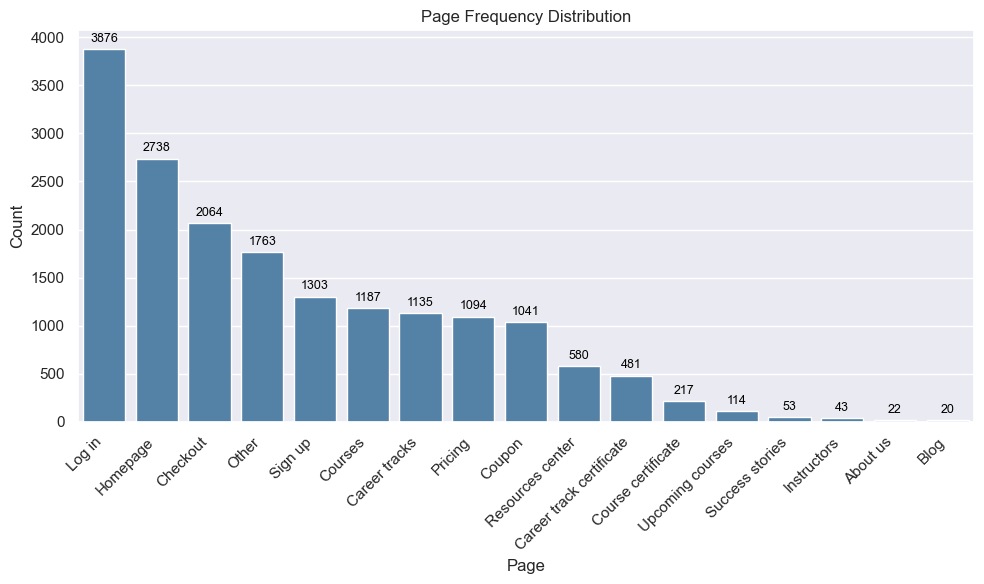

In [30]:
bar_plot_visualizer(res_dfs[0], x_col='page', y_col='values')

### Page Presence

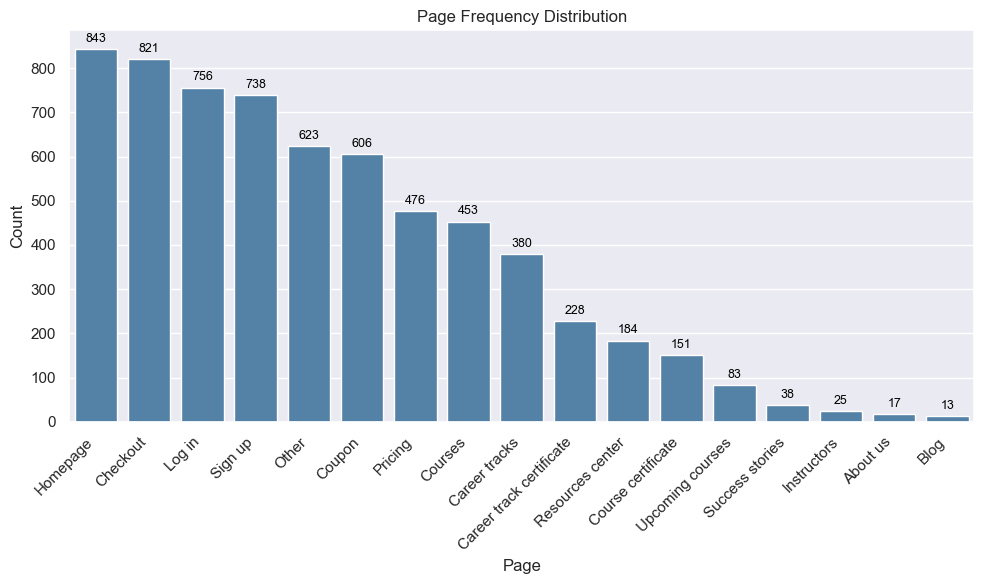

In [31]:
bar_plot_visualizer(res_dfs[1], x_col='index', y_col='value')

### Page Destination

#### Courses

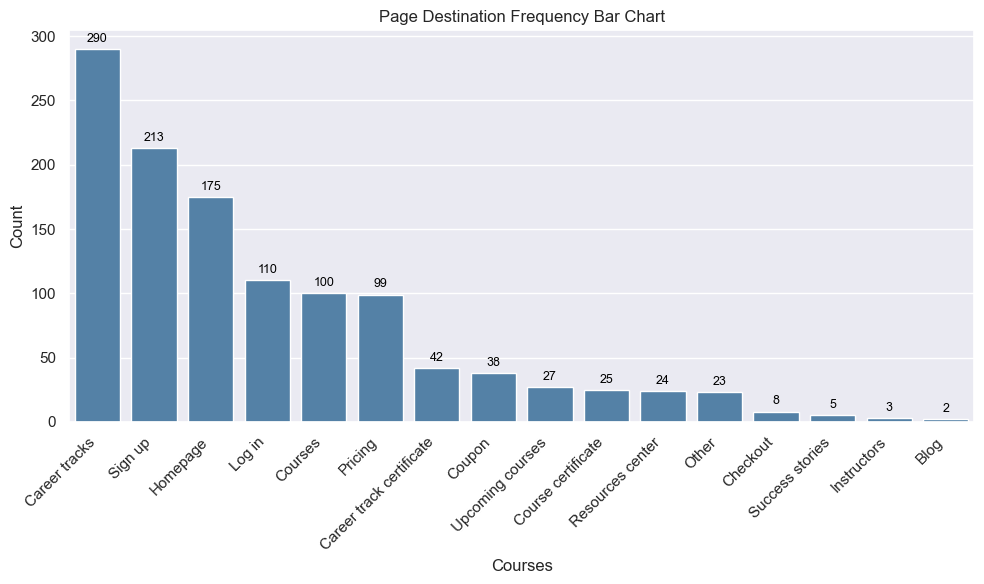

In [32]:
bar_plot_visualizer(data=res_dfs[2], 
                    x_col='index', y_col='value', 
                    title='Page Destination Frequency Bar Chart',
                    page='Courses')

#### Pricing

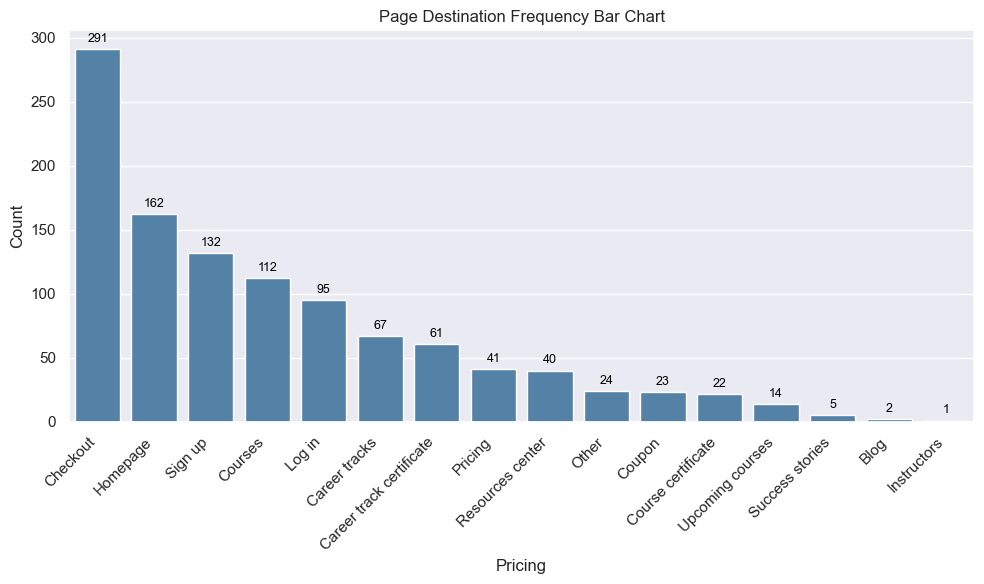

In [33]:
pg_destination = page_destination(preprocessed_dfs[1], 'Pricing')
pg_dest_df = results_converter(pg_destination)
bar_plot_visualizer(data=pg_dest_df, 
                    x_col='index', y_col='value', 
                    title='Page Destination Frequency Bar Chart',
                    page='Pricing')

### Page Sequence

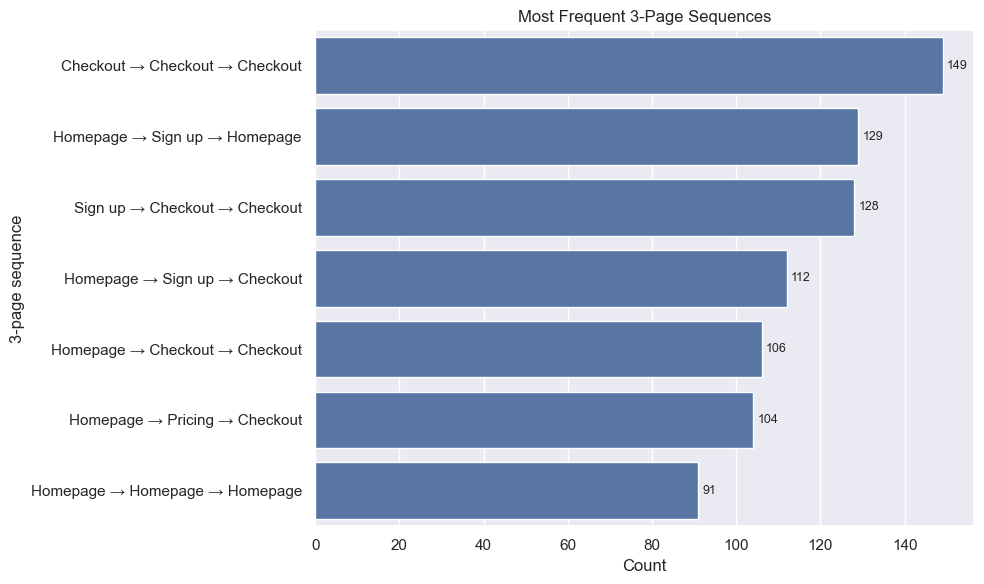

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = res_dfs[3].copy()

def to_label(x):
    if isinstance(x, (list, tuple)):
        return " → ".join(map(str, x))
    return str(x)

df["page_label"] = df["page"].apply(to_label)

df = df.sort_values("values", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, y="page_label", x="values")

for p in ax.patches:
    w = p.get_width()
    ax.annotate(f"{int(w)}",
                (w, p.get_y() + p.get_height()/2),
                ha="left", va="center", fontsize=9,
                xytext=(3, 0), textcoords="offset points")

ax.set_xlabel("Count")
ax.set_ylabel("3-page sequence")
ax.set_title("Most Frequent 3-Page Sequences")
plt.tight_layout()
plt.show()
